# **Analisis Pengaruh Faktor Iklim dan Kepadatan Penduduk terhadap Kasus Demam Berdarah Dengue (DBD) Menurut Provinsi di Indonesia Tahun 2019–2020**

**PROJECT AKHIR DATA WRANGLING**

Disusun oleh:

- Siti Fadilah Nurkhotimah
- Laili Nurrohmatul Fadhila Zulfa

---



# **Dataset Iklim**

Sumber Data: Kaggle

https://www.kaggle.com/datasets/greegtitan/indonesia-climate

**Keterangan:**

Tn = Suhu minimum (°C)

Tx = Suhu maksimum (°C)

Tavg = Suhu rata-rata (°C)

RH_avg = kelembaban rata-rata (%)

RR = curah hujan (mm)

ss = durasi sinar matahari (jam)

ff_x = kecepatan angin maksimum (m/s)

ddd_x = arah angin pada kecepatan maksimum (°)

ff_avg = kecepatan angin rata-rata (m/s)

ddd_car = arah angin dominan (°)

## **PENGAMBILAN DATA**

In [ ]:
import pandas as pd

# === LOAD DATA ===
df_climate = pd.read_csv("climate_data.csv")
df_station = pd.read_csv("station_detail.csv")
df_prov = pd.read_csv("province_detail.csv")

> climate_data.csv

In [ ]:
df_climate

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id
0,01-01-2010,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001
1,02-01-2010,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001
2,03-01-2010,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001
3,04-01-2010,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001
4,05-01-2010,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001
...,...,...,...,...,...,...,...,...,...,...,...,...
589260,27-12-2020,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980
589261,28-12-2020,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980
589262,29-12-2020,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980
589263,30-12-2020,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980


> station_detail.csv

In [ ]:
df_station

,station_id,station_name,region_name,latitude,longitude,region_id,province_id
0,96001,Stasiun Meteorologi Maimun Saleh,Kota Sabang,5.87655,95.33785,20,1
1,96003,Balai Besar Meteorologi Klimatologi dan Geofi...,Kab. Badung,-8.73810,115.17860,272,17
2,96004,Balai Besar Meteorologi Klimatologi dan Geofis...,Kota Makassar,-5.14283,119.45227,412,26
3,96009,Stasiun Meteorologi Malikussaleh,Kab. Aceh Utara,5.22869,96.94749,8,1
4,96011,Stasiun Meteorologi Sultan Iskandar Muda,Kab. Aceh Besar,5.52244,95.41700,6,1
...,...,...,...,...,...,...,...
187,97876,Stasiun Meteorologi Tanah Merah,Kab. Boven Digoel,-6.10000,140.31000,473,32
188,97900,Stasiun Meteorologi Mathilda Batlayeri,Kab Maluku Tenggara Barat,-7.98000,131.30000,440,30
189,97902,Stasiun Geofisika Maluku Tenggara Barat,Kab Maluku Tenggara Barat,-7.98000,131.30000,440,30
190,97978,Stasiun Klimatologi Merauke,Kab. Merauke,-8.38700,140.51700,458,32


> province_detail.csv

In [ ]:
df_prov

,province_id,province_name
0,1,Nanggroe Aceh Darussalam
1,2,Sumatera Utara
2,3,Sumatera Barat
3,4,Riau
4,5,Jambi
5,6,Sumatera Selatan
6,7,Bengkulu
7,8,Lampung
8,9,Kep. Bangka Belitung
9,10,Kep. Riau


## INTEGRASI DATA

Integrasi (menyamakan format nama provinsi)

In [ ]:
# sesuaiin kolom Provinsi
df_prov["province_name"] = df_prov["province_name"].str.title()

df_prov["province_name"] = df_prov["province_name"].replace({"Nanggroe Aceh Darussalam": "Aceh", "Dki Jakarta" : 'DKI Jakarta', 'Di Yogyakarta' : 'DI Yogyakarta'})
df_prov['province_name']

,province_name
0,Aceh
1,Sumatera Utara
2,Sumatera Barat
3,Riau
4,Jambi
5,Sumatera Selatan
6,Bengkulu
7,Lampung
8,Kep. Bangka Belitung
9,Kep. Riau


In [ ]:
df_prov

,province_id,province_name
0,1,Aceh
1,2,Sumatera Utara
2,3,Sumatera Barat
3,4,Riau
4,5,Jambi
5,6,Sumatera Selatan
6,7,Bengkulu
7,8,Lampung
8,9,Kep. Bangka Belitung
9,10,Kep. Riau


> climate_data.csv

In [ ]:
df_climate

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id
0,01-01-2010,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001
1,02-01-2010,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001
2,03-01-2010,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001
3,04-01-2010,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001
4,05-01-2010,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001
...,...,...,...,...,...,...,...,...,...,...,...,...
589260,27-12-2020,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980
589261,28-12-2020,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980
589262,29-12-2020,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980
589263,30-12-2020,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980


In [ ]:
df_climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589265 entries, 0 to 589264
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        589265 non-null  object 
 1   Tn          565882 non-null  float64
 2   Tx          551529 non-null  float64
 3   Tavg        544160 non-null  float64
 4   RH_avg      541083 non-null  float64
 5   RR          463881 non-null  float64
 6   ss          545544 non-null  float64
 7   ff_x        579051 non-null  float64
 8   ddd_x       576137 non-null  float64
 9   ff_avg      579138 non-null  float64
 10  ddd_car     575526 non-null  object 
 11  station_id  589265 non-null  int64  
dtypes: float64(9), int64(1), object(2)
memory usage: 53.9+ MB


In [ ]:
df_climate['station_id'].unique()[:20]

array([96001, 96009, 96011, 96015, 96017, 96031, 96033, 96035, 96037,
       96039, 96041, 96043, 96071, 96073, 96075, 96077, 96087, 96089,
       96091, 96107])

In [ ]:
df_climate.loc[:, 'station_id'] = df_climate['station_id'].astype(int)

Integrasi (menggabung dataset iklim dengan dataset stasiun)

In [ ]:
# MERGE climate_data.csv (df_climate) + station_detail.csv (df_station)
df_merge1 = df_climate.merge(df_station[['station_id', 'province_id']], on='station_id', how='left')
df_merge1

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id
0,01-01-2010,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001,1
1,02-01-2010,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001,1
2,03-01-2010,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001,1
3,04-01-2010,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001,1
4,05-01-2010,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,27-12-2020,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32
589261,28-12-2020,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980,32
589262,29-12-2020,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980,32
589263,30-12-2020,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32


Integrasi (Menggabung dataset dari gabungan iklim dan stasiun dengan dataset provinsi)

In [ ]:
# MERGE dengan province_detail.csv (df_prov)
df_final = df_merge1.merge(df_prov, on='province_id', how='left')
df_final

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id,province_name
0,01-01-2010,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001,1,Aceh
1,02-01-2010,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001,1,Aceh
2,03-01-2010,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001,1,Aceh
3,04-01-2010,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001,1,Aceh
4,05-01-2010,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001,1,Aceh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,27-12-2020,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32,Papua
589261,28-12-2020,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980,32,Papua
589262,29-12-2020,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980,32,Papua
589263,30-12-2020,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32,Papua


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589265 entries, 0 to 589264
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           589265 non-null  object 
 1   Tn             565882 non-null  float64
 2   Tx             551529 non-null  float64
 3   Tavg           544160 non-null  float64
 4   RH_avg         541083 non-null  float64
 5   RR             463881 non-null  float64
 6   ss             545544 non-null  float64
 7   ff_x           579051 non-null  float64
 8   ddd_x          576137 non-null  float64
 9   ff_avg         579138 non-null  float64
 10  ddd_car        575526 non-null  object 
 11  station_id     589265 non-null  int64  
 12  province_id    589265 non-null  int64  
 13  province_name  589265 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 62.9+ MB


In [ ]:
#Standarisasi format datetime
df_final['date'] = pd.to_datetime(df_final['date'], format='%d-%m-%Y', errors='coerce')
df_final

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id,province_name
0,2010-01-01,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001,1,Aceh
1,2010-01-02,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001,1,Aceh
2,2010-01-03,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001,1,Aceh
3,2010-01-04,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001,1,Aceh
4,2010-01-05,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001,1,Aceh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,2020-12-27,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32,Papua
589261,2020-12-28,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980,32,Papua
589262,2020-12-29,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980,32,Papua
589263,2020-12-30,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32,Papua


In [ ]:
df_final['year'] = df_final['date'].dt.year
df_final

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id,province_name,year
0,2010-01-01,21.4,30.2,27.1,82.0,9.0,0.5,7.0,90.0,5.0,E,96001,1,Aceh,2010
1,2010-01-02,21.0,29.6,25.7,95.0,24.0,0.2,6.0,90.0,4.0,E,96001,1,Aceh,2010
2,2010-01-03,20.2,26.8,24.5,98.0,63.0,0.0,5.0,90.0,4.0,E,96001,1,Aceh,2010
3,2010-01-04,21.0,29.2,25.8,90.0,0.0,0.1,4.0,225.0,3.0,SW,96001,1,Aceh,2010
4,2010-01-05,21.2,30.0,26.7,90.0,2.0,0.4,NaN,NaN,NaN,NaN,96001,1,Aceh,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,2020-12-27,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32,Papua,2020
589261,2020-12-28,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980,32,Papua,2020
589262,2020-12-29,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980,32,Papua,2020
589263,2020-12-30,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32,Papua,2020


In [ ]:
# Memfilter tahun 2019-2020
df_final = df_final[df_final['year'].isin([2019, 2020])].copy()
df_final

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id,province_name,year
3182,2019-01-01,23.2,30.6,26.5,86.0,NaN,8.5,4.0,110.0,2.0,E,96001,1,Aceh,2019
3183,2019-01-02,23.6,30.6,27.3,84.0,NaN,9.0,5.0,100.0,2.0,C,96001,1,Aceh,2019
3184,2019-01-03,24.8,30.8,28.0,77.0,NaN,6.5,4.0,70.0,2.0,E,96001,1,Aceh,2019
3185,2019-01-04,25.4,30.4,27.3,78.0,NaN,7.5,4.0,90.0,1.0,C,96001,1,Aceh,2019
3186,2019-01-05,23.8,31.6,26.7,80.0,NaN,8.0,4.0,250.0,1.0,C,96001,1,Aceh,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,2020-12-27,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32,Papua,2020
589261,2020-12-28,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980,32,Papua,2020
589262,2020-12-29,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980,32,Papua,2020
589263,2020-12-30,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32,Papua,2020




## CLEANING DATA

In [ ]:
# penggantian nama kolom
df_final = df_final.rename(columns={'province_name': 'provinsi', 'year' : "tahun"})
df_final

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id,provinsi,tahun
3182,2019-01-01,23.2,30.6,26.5,86.0,NaN,8.5,4.0,110.0,2.0,E,96001,1,Aceh,2019
3183,2019-01-02,23.6,30.6,27.3,84.0,NaN,9.0,5.0,100.0,2.0,C,96001,1,Aceh,2019
3184,2019-01-03,24.8,30.8,28.0,77.0,NaN,6.5,4.0,70.0,2.0,E,96001,1,Aceh,2019
3185,2019-01-04,25.4,30.4,27.3,78.0,NaN,7.5,4.0,90.0,1.0,C,96001,1,Aceh,2019
3186,2019-01-05,23.8,31.6,26.7,80.0,NaN,8.0,4.0,250.0,1.0,C,96001,1,Aceh,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,2020-12-27,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32,Papua,2020
589261,2020-12-28,25.3,31.6,28.1,78.0,NaN,3.0,12.0,260.0,2.0,C,97980,32,Papua,2020
589262,2020-12-29,24.6,32.3,28.4,81.0,NaN,6.5,5.0,260.0,2.0,SW,97980,32,Papua,2020
589263,2020-12-30,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32,Papua,2020


In [ ]:
#Mengubah NaN menjadi angka 0
df_final = df_final.fillna(0)
df_final

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,province_id,provinsi,tahun
3182,2019-01-01,23.2,30.6,26.5,86.0,0.0,8.5,4.0,110.0,2.0,E,96001,1,Aceh,2019
3183,2019-01-02,23.6,30.6,27.3,84.0,0.0,9.0,5.0,100.0,2.0,C,96001,1,Aceh,2019
3184,2019-01-03,24.8,30.8,28.0,77.0,0.0,6.5,4.0,70.0,2.0,E,96001,1,Aceh,2019
3185,2019-01-04,25.4,30.4,27.3,78.0,0.0,7.5,4.0,90.0,1.0,C,96001,1,Aceh,2019
3186,2019-01-05,23.8,31.6,26.7,80.0,0.0,8.0,4.0,250.0,1.0,C,96001,1,Aceh,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589260,2020-12-27,25.2,31.2,29.2,74.0,0.0,1.4,4.0,280.0,2.0,C,97980,32,Papua,2020
589261,2020-12-28,25.3,31.6,28.1,78.0,0.0,3.0,12.0,260.0,2.0,C,97980,32,Papua,2020
589262,2020-12-29,24.6,32.3,28.4,81.0,0.0,6.5,5.0,260.0,2.0,SW,97980,32,Papua,2020
589263,2020-12-30,25.2,32.6,28.4,80.0,0.0,2.4,7.0,260.0,2.0,C,97980,32,Papua,2020


### AGREGASI DATASET IKLIM

In [ ]:
df_iklim = df_final.groupby(['provinsi', 'tahun'], as_index=False)[['Tn','Tx','Tavg','RH_avg','RR','ss','ff_x','ff_avg']].mean()
df_iklim

,provinsi,tahun,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ff_avg
0,Aceh,2019,22.222540,31.806597,26.926113,82.631116,5.108136,5.298241,4.768554,2.029137
1,Aceh,2020,22.585217,31.211014,26.647188,82.925797,6.971478,4.980986,4.948986,2.228406
2,Bali,2019,21.755720,18.356379,7.971193,23.211523,3.221399,7.887984,5.146502,2.876543
3,Bali,2020,22.710836,22.479745,6.780382,19.615439,5.141006,6.774363,5.028329,2.833569
4,Banten,2019,23.398081,32.967982,27.783279,77.977522,3.678893,4.911513,4.359649,1.597588
...,...,...,...,...,...,...,...,...,...,...
63,Sumatera Barat,2020,21.149140,30.053820,20.442602,66.844460,11.031039,5.157949,3.717137,1.255334
64,Sumatera Selatan,2019,23.162329,32.778493,27.528082,82.764384,5.860548,5.108082,4.539726,2.149315
65,Sumatera Selatan,2020,23.962606,31.927479,27.470538,84.344193,7.515581,4.518130,4.184136,1.831445
66,Sumatera Utara,2019,22.155954,31.835362,25.963750,81.068092,7.479408,4.393586,4.038816,1.234211


In [ ]:
# Save data gabungan iklim dan provinsi
df_iklim.to_csv("iklim_2019-2020.csv", index=False)

# **Dataset Kepadatan Penduduk**

Sumber Data: Badan Pusat Statistik (BPS)

https://www.bps.go.id/id/statistics-table/2/MTQxIzI=/population-density-by-province.html untuk Tahun 2019 dan 2020

**Keterangan:**

38 Provinsi = 38 Provinsi di Indonesia

Unnamed: 1 = Kepadatan Penduduk menurut Provinsi (jiwa/km2) di Indonesia

## **PENGAMBILAN DATA**

In [ ]:
import pandas as pd

df19 = pd.read_csv("Kepadatan Penduduk menurut Provinsi, 2019.csv")
df20 = pd.read_csv("Kepadatan Penduduk menurut Provinsi, 2020.csv")

KEPADATAN PENDUDUK 2019

In [ ]:
df19

,38 Provinsi,Unnamed: 1
0,NaN,Kepadatan Penduduk menurut Provinsi (jiwa/km2)
1,NaN,2019
2,ACEH,93
3,SUMATERA UTARA,200
4,SUMATERA BARAT,130
5,RIAU,80
6,JAMBI,72
7,SUMATERA SELATAN,92
8,BENGKULU,100
9,LAMPUNG,244


KEPADATAN PENDUDUK 2020

In [ ]:
df20

,38 Provinsi,Unnamed: 1
0,NaN,Kepadatan Penduduk menurut Provinsi (jiwa/km2)
1,NaN,2020
2,ACEH,91
3,SUMATERA UTARA,203
4,SUMATERA BARAT,132
5,RIAU,73
6,JAMBI,71
7,SUMATERA SELATAN,92
8,BENGKULU,101
9,LAMPUNG,260


## CLEANING DATA

### cleaning data 2019

In [ ]:
#Standarisasi Nama kolom
df19 = df19.rename(columns={
    'Unnamed: 1': 'kepadatan 2019',
    '38 Provinsi' : 'provinsi'
})
df19

,provinsi,kepadatan 2019
0,NaN,Kepadatan Penduduk menurut Provinsi (jiwa/km2)
1,NaN,2019
2,ACEH,93
3,SUMATERA UTARA,200
4,SUMATERA BARAT,130
5,RIAU,80
6,JAMBI,72
7,SUMATERA SELATAN,92
8,BENGKULU,100
9,LAMPUNG,244


In [ ]:
# drop 2 baris NaN di atas (index 0 dan 1)
df19_1= df19.iloc[2:].reset_index(drop=True)

In [ ]:
df19_1

,provinsi,kepadatan 2019
0,ACEH,93
1,SUMATERA UTARA,200
2,SUMATERA BARAT,130
3,RIAU,80
4,JAMBI,72
5,SUMATERA SELATAN,92
6,BENGKULU,100
7,LAMPUNG,244
8,KEP. BANGKA BELITUNG,91
9,KEP. RIAU,267


In [ ]:
# Mengubah tipe kolom menjadi numerik
df19_1['kepadatan 2019'] = pd.to_numeric(df19_1['kepadatan 2019'], errors='coerce')

In [ ]:
# hapus baris kosong
df19 = df19_1.dropna(subset=['provinsi', 'kepadatan 2019'])
df19

,provinsi,kepadatan 2019
0,ACEH,93.0
1,SUMATERA UTARA,200.0
2,SUMATERA BARAT,130.0
3,RIAU,80.0
4,JAMBI,72.0
5,SUMATERA SELATAN,92.0
6,BENGKULU,100.0
7,LAMPUNG,244.0
8,KEP. BANGKA BELITUNG,91.0
9,KEP. RIAU,267.0


In [ ]:
df19 = df19[df19['provinsi'] != 'INDONESIA'].copy()
df19

,provinsi,kepadatan 2019
0,ACEH,93.0
1,SUMATERA UTARA,200.0
2,SUMATERA BARAT,130.0
3,RIAU,80.0
4,JAMBI,72.0
5,SUMATERA SELATAN,92.0
6,BENGKULU,100.0
7,LAMPUNG,244.0
8,KEP. BANGKA BELITUNG,91.0
9,KEP. RIAU,267.0


### cleaning data 2020

In [ ]:
# drop 2 baris NaN kepadatan penduduk 2020 (index 0 dan 1)
df20_1 = df20.iloc[2:].reset_index(drop=True)
df20_1

,38 Provinsi,Unnamed: 1
0,ACEH,91
1,SUMATERA UTARA,203
2,SUMATERA BARAT,132
3,RIAU,73
4,JAMBI,71
5,SUMATERA SELATAN,92
6,BENGKULU,101
7,LAMPUNG,260
8,KEP. BANGKA BELITUNG,89
9,KEP. RIAU,252


In [ ]:
# rename kolom
df20_1 = df20_1.rename(columns={
    'Unnamed: 1': 'kepadatan 2020',
    '38 Provinsi': 'provinsi'})
df20_1

,provinsi,kepadatan 2020
0,ACEH,91
1,SUMATERA UTARA,203
2,SUMATERA BARAT,132
3,RIAU,73
4,JAMBI,71
5,SUMATERA SELATAN,92
6,BENGKULU,101
7,LAMPUNG,260
8,KEP. BANGKA BELITUNG,89
9,KEP. RIAU,252


In [ ]:
# Mengubah tipe kolom menjadi numerik
df20_1['kepadatan 2020'] = pd.to_numeric(df20_1['kepadatan 2020'], errors='coerce')

In [ ]:
# Menghapus baris kosong
df20 = df20_1.dropna(subset=['provinsi', 'kepadatan 2020'])
df20

,provinsi,kepadatan 2020
0,ACEH,91.0
1,SUMATERA UTARA,203.0
2,SUMATERA BARAT,132.0
3,RIAU,73.0
4,JAMBI,71.0
5,SUMATERA SELATAN,92.0
6,BENGKULU,101.0
7,LAMPUNG,260.0
8,KEP. BANGKA BELITUNG,89.0
9,KEP. RIAU,252.0


In [ ]:
df20 = df20[df20['provinsi'] != 'INDONESIA'].copy()
df20

,provinsi,kepadatan 2020
0,ACEH,91.0
1,SUMATERA UTARA,203.0
2,SUMATERA BARAT,132.0
3,RIAU,73.0
4,JAMBI,71.0
5,SUMATERA SELATAN,92.0
6,BENGKULU,101.0
7,LAMPUNG,260.0
8,KEP. BANGKA BELITUNG,89.0
9,KEP. RIAU,252.0


## INTEGRASI DATA

In [ ]:
# Menggabungkan dataset 2019 dan 2020
df_kepduk = df19.merge(df20, on='provinsi', how='inner')
df_kepduk

,provinsi,kepadatan 2019,kepadatan 2020
0,ACEH,93.0,91.0
1,SUMATERA UTARA,200.0,203.0
2,SUMATERA BARAT,130.0,132.0
3,RIAU,80.0,73.0
4,JAMBI,72.0,71.0
5,SUMATERA SELATAN,92.0,92.0
6,BENGKULU,100.0,101.0
7,LAMPUNG,244.0,260.0
8,KEP. BANGKA BELITUNG,91.0,89.0
9,KEP. RIAU,267.0,252.0


In [ ]:
# Mengubah nama kolom menjadi title
df_kepduk['provinsi'] = df_kepduk['provinsi'].str.title()

df_kepduk["provinsi"] = df_kepduk["provinsi"].replace({"Dki Jakarta" : 'DKI Jakarta', 'Di Yogyakarta' : 'DI Yogyakarta'})
df_kepduk

,provinsi,kepadatan 2019,kepadatan 2020
0,Aceh,93.0,91.0
1,Sumatera Utara,200.0,203.0
2,Sumatera Barat,130.0,132.0
3,Riau,80.0,73.0
4,Jambi,72.0,71.0
5,Sumatera Selatan,92.0,92.0
6,Bengkulu,100.0,101.0
7,Lampung,244.0,260.0
8,Kep. Bangka Belitung,91.0,89.0
9,Kep. Riau,267.0,252.0


In [ ]:
df_kepduk.columns

Index(['provinsi', 'kepadatan 2019', 'kepadatan 2020'], dtype='object')

In [ ]:
df_kepduk = df_kepduk.melt(
    id_vars='provinsi',
    value_vars=['kepadatan 2019', 'kepadatan 2020'],
    var_name='tahun',
    value_name='KP'
)
df_kepduk

,provinsi,tahun,KP
0,Aceh,kepadatan 2019,93.0
1,Sumatera Utara,kepadatan 2019,200.0
2,Sumatera Barat,kepadatan 2019,130.0
3,Riau,kepadatan 2019,80.0
4,Jambi,kepadatan 2019,72.0
...,...,...,...
63,Sulawesi Barat,kepadatan 2020,85.0
64,Maluku,kepadatan 2020,39.0
65,Maluku Utara,kepadatan 2020,40.0
66,Papua Barat,kepadatan 2020,11.0


In [ ]:
df_kepduk['tahun'] = df_kepduk['tahun'].str.extract('(\d+)').astype(int)
df_kepduk

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2932287119.py:1: SyntaxWarning: invalid escape sequence '\d'
  df_kepduk['tahun'] = df_kepduk['tahun'].str.extract('(\d+)').astype(int)


,provinsi,tahun,KP
0,Aceh,2019,93.0
1,Sumatera Utara,2019,200.0
2,Sumatera Barat,2019,130.0
3,Riau,2019,80.0
4,Jambi,2019,72.0
...,...,...,...
63,Sulawesi Barat,2020,85.0
64,Maluku,2020,39.0
65,Maluku Utara,2020,40.0
66,Papua Barat,2020,11.0


In [ ]:
# Save data gabungan ke csv
df_kepduk.to_csv("kepadatan_penduduk_2019-2020.csv", index=False)

# **Dataset DBD (Demam Berdarah Dengue)**

Sumber Data: Kementerian Kesehatan Republik Indonesia

Publikasi Tahunan Profil Kesehatan Indonesia

https://www.kemkes.go.id/id/category-download/profil-kesehatan untuk Tahun 2019 dan 2020

**Keterangan:**

Provinsi = 34 Provinsi di Indonesia

Jumlah Penduduk = Jumlah Penduduk Menurut Provinsi di Indonesia

Jumlah Kasus = Jumlah Kasus DBD Menurut Provinsi di Indonesia

Incidence Rate per 100.000 Penduduk = Tingkat Insidensi DBD per 100.000 Penduduk Provinsi

Meninggal = Jumlah Penduduk Meninggal Menurut Provinsi di Indonesia

CFR (%) = *Case Fatality Rate* (CFR) / Tingkat Kematian Kasus DBD (%) Menurut Provinsi di Indonesia

## PENGAMBILAN DATA

### Unggah File PDF



> **Instal pustaka yang dibutuhkan**






In [ ]:
!pip install tabula-py pandas pyreadstat openpyxl PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 56.5 MB/s eta 0:00:00




> **Impor modul**



In [ ]:
import pandas as pd
import os
import pyreadstat
import tabula
import fitz

> **Unggah File PDF "Profil-Kesehatan-Indonesia-2019.pdf" dan "Profil-Kesehatan-Indonesia-2020.pdf"**




In [ ]:
# from google.colab import files

#upload file PDF dari laptop ke Google Colab
# uploaded = files.upload()



### Read File PDF



> Profil Kesehatan Indonesia 2019.pdf

In [ ]:
# Profil-Kesehatan-Indonesia-2019.pdf

PDF_2019 = 'Profil-Kesehatan-Indonesia-2019.pdf'
PDF_PATH_2019 = f'/content/{PDF_2019}'
print(f"File PDF telah diunggah ke path")
print(f"Path PDF: {PDF_PATH_2019}")

File PDF telah diunggah ke path
Path PDF: /content/Profil-Kesehatan-Indonesia-2019.pdf


In [ ]:
doc1 = fitz.open(PDF_2019)
doc1

Document('Profil-Kesehatan-Indonesia-2019.pdf')

In [ ]:
print('Number of pages: ', doc1.page_count) #total page/halaman

Number of pages:  487


> Profil Kesehatan Indonesia 2020.pdf

In [ ]:
# Profil-Kesehatan-Indonesia-2020.pdf

PDF_2020 = 'Profil-Kesehatan-Indonesia-2020.pdf'
PDF_PATH_2020 = f'/content/{PDF_2020}'
print(f"File PDF telah diunggah ke path")
print(f"Path PDF: {PDF_PATH_2020}")

File PDF telah diunggah ke path
Path PDF: /content/Profil-Kesehatan-Indonesia-2020.pdf


In [ ]:
doc2 = fitz.open(PDF_2020)
doc2

Document('Profil-Kesehatan-Indonesia-2020.pdf')

In [ ]:
print('Number of pages: ', doc2.page_count) #total page/halaman

Number of pages:  480


### Scraping Tabel PDF

#### Scraping Tabel PDF 2019



> Scraping/Ekstraksi keseluruhan tabel dari PDF Profil Kesehatan Indonesia 2019



In [ ]:
total_tables_2019 = 0

print(f"Mencari seluruh tabel di file: {PDF_2019}\n")
for page_num in range(len(doc1)):
    page = doc1[page_num]
    tables = page.find_tables()
    if tables.tables:
        print(f"Ditemukan tabel di Halaman {page_num + 1}")
        for i, table in enumerate(tables):
            table_data = table.extract()
            print(f"--- Data Tabel {i+1} ---")
            for row in table_data:
                print(row)
            print("--------------------\n")
            total_tables_2019 += 1  #tambah 1 setiap kali tabel ditemukan

# tampilkan hasil total tabel di seluruh PDF
print(f"\nDitemukan total {total_tables_2019} tabel di seluruh halaman PDF.\n")

Output streaming akan dipotong hingga 5000 baris terakhir.
['22', 'Kalimantan Selatan', '546', '349', '895', '17', '6', '23', '2.818', '2.956', '5.774', '3.381', '3.311', '6.692']
['23', 'Kalimantan Timur', '451', '378', '829', '2', '1', '3', '2.840', '3.009', '5.849', '3.293', '3.388', '6.681']
['24', 'Kalimantan Utara', '121', '110', '231', '1', '0', '1', '945', '862', '1.807', '1.067', '972', '2.039']
['25', 'Sulawesi Utara', '211', '349', '560', '1', '6', '7', '926', '1.448', '2.374', '1.138', '1.803', '2.941']
['26', 'Sulawesi Tengah', '286', '297', '583', '3', '13', '16', '1.458', '1.910', '3.368', '1.747', '2.220', '3.967']
['27', 'Sulawesi Selatan', '597', '720', '1.317', '0', '3', '3', '2.468', '3.138', '5.606', '3.065', '3.861', '6.926']
['28', 'Sulawesi Tenggara', '354', '372', '726', '3', '5', '8', '906', '1.335', '2.241', '1.263', '1.712', '2.975']
['29', 'Gorontalo', '138', '180', '318', '1', '2', '3', '796', '1.235', '2.031', '935', '1.417', '2.352']
['30', 'Sulawesi Bar

Oleh karena tabel yang diinginkan sebagai Dataset 3 mengenai Kasus Demam Berdarah Dengue (DBD) Menurut Provinsi di Indonesia Tahun 2019 berada pada halaman 458, maka proses ekstraksi data difokuskan hanya pada halaman tersebut yang diambil dari Profil-Kesehatan-Indonesia-2019.pdf

In [ ]:
# Ambil halaman 458 => index Python = 457
page = doc1[457]
tables = page.find_tables()

dfs = []  # list menampung tabel sebagai DataFrame

# Ekstraksi tabel dari halaman 458
for table in tables:
    table_data = table.extract()
    df = pd.DataFrame(table_data[1:], columns=table_data[0])
    dfs.append(df)

dfs

[                       No                   Provinsi Jumlah Penduduk  \
 0                     (1)                        (2)             (3)   
 1                       1                       Aceh       5.371.532   
 2                       2             Sumatera Utara      14.562.549   
 3                       3             Sumatera Barat       5.441.197   
 4                       4                       Riau       6.971.745   
 5                       5                      Jambi       3.624.579   
 6                       6           Sumatera Selatan       8.470.683   
 7                       7                   Bengkulu       1.991.838   
 8                       8                    Lampung       8.447.737   
 9                       9  Kepulauan Bangka Belitung       1.488.792   
 10                     10             Kepulauan Riau       2.189.653   
 11                     11                DKI Jakarta      10.557.810   
 12                     12                 Jawa Bar

In [ ]:
# Karena tabel di page 458 hanya 1, maka dfs[0]
df_dbd_2019 = dfs[0]

#### Scraping Tabel PDF 2020



> Scraping/Ekstraksi keseluruhan tabel dari PDF Profil Kesehatan Indonesia 2020



In [ ]:
total_tables_2020 = 0

print(f"Mencari seluruh tabel di file: {PDF_2020}\n")
for page_num in range(len(doc2)):
    page = doc2[page_num]
    tables = page.find_tables()
    if tables.tables:
        print(f"Ditemukan tabel di Halaman {page_num + 1}")
        for i, table in enumerate(tables):
            table_data = table.extract()
            print(f"--- Data Tabel {i+1} ---")
            for row in table_data:
                print(row)
            print("--------------------\n")
            total_tables_2020 += 1  #tambah 1 setiap kali tabel ditemukan

# tampilkan hasil total tabel di seluruh PDF
print(f"\nDitemukan total {total_tables_2020} tabel di seluruh halaman PDF.\n")

Output streaming akan dipotong hingga 5000 baris terakhir.
['32', 'Maluku Utara', '176', '164', '340', '0', '0', '0', '467', '599', '1.066', '643', '763', '1.406']
['33', 'Papua Barat', '240', '150', '390', '0', '0', '0', '716', '702', '1.418', '956', '852', '1.808']
['34', 'Papua', '472', '359', '831', '8', '9', '17', '1.722', '1.759', '3.481', '2.202', '2.127', '4.329']
['Indonesia', None, '16.998', '17.806', '34.804', '267', '469', '736', '178.405', '176.828', '355.233', '195.670', '195.103', '390.773']
--------------------

Ditemukan tabel di Halaman 359
--- Data Tabel 1 ---
['No', 'Provinsi', 'Tenaga Penunjang/Pendukung Kesehatan', None, None, None, None, None, None, None, None, 'Total', None, None]
[None, None, 'Pejabat Struktural', None, None, 'Tenaga Pendidik', None, None, 'Tenaga Dukungan Manajemen', None, None, None, None, None]
[None, None, 'L', 'P', 'L+P', 'L', 'P', 'L+P', 'L', 'P', 'L+P', 'L', 'P', 'L+P']
['(1)', '(2)', '(3)', '(4)', '(5)', '(6)', '(7)', '(8)', '(9)', '(10

Oleh karena tabel yang diinginkan sebagai Dataset 3 mengenai Kasus Demam Berdarah Dengue (DBD) Menurut Provinsi di Indonesia Tahun 2020 berada pada halaman 453, maka proses ekstraksi data difokuskan hanya pada halaman tersebut yang diambil dari Profil-Kesehatan-Indonesia-2020.pdf

In [ ]:
# Ambil halaman 453 => index Python = 452
page_2 = doc2[452]
tables_2 = page_2.find_tables()

dfs_2 = []  # list menampung tabel sebagai DataFrame

# Ekstraksi tabel dari halaman 458
for table in tables_2:
    table_data = table.extract()
    df = pd.DataFrame(table_data[1:], columns=table_data[0])
    dfs_2.append(df)

dfs_2

[                       No                   Provinsi Jumlah Penduduk  \
 0                     (1)                        (2)             (3)   
 1                       1                       Aceh       5.459.891   
 2                       2             Sumatera Utara      14.703.532   
 3                       3             Sumatera Barat       5.498.751   
 4                       4                       Riau       7.128.305   
 5                       5                      Jambi       3.677.894   
 6                       6           Sumatera Selatan       8.567.923   
 7                       7                   Bengkulu       2.019.848   
 8                       8                    Lampung       8.521.201   
 9                       9  Kepulauan Bangka Belitung       1.517.590   
 10                     10             Kepulauan Riau       2.242.198   
 11                     11                DKI Jakarta      10.644.986   
 12                     12                 Jawa Bar

In [ ]:
# Karena tabel di page 453 hanya 1, maka dfs[0]
df_dbd_2020 = dfs_2[0]

## CLEANING DATA DBD 2019

In [ ]:
# hapus baris index 0 dan 35 karena bukan data yang digunakan dan bukan provinsi (melainkan Indonesia)
# hapus kolom No (Nomor)
df_dbd_2019 = df_dbd_2019.drop(columns=["No"]).drop(index=[0, 35]).reset_index(drop=True)

In [ ]:
# Informasi sebelum tipe data diubah
df_dbd_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Provinsi                             34 non-null     object
 1   Jumlah Penduduk                      34 non-null     object
 2   Jumlah Kasus                         34 non-null     object
 3   Incidence Rate per
100.000 Penduduk  34 non-null     object
 4   Meninggal                            34 non-null     object
 5   CFR (%)                              34 non-null     object
dtypes: object(6)
memory usage: 1.7+ KB


> Ubah tipe data dari object menjadi sesuai format bertipe numerik untuk kolom tertentu

In [ ]:
# Hapus titik pemisah ribuan & ubah koma ke titik
cols_int = ["Jumlah Penduduk", "Jumlah Kasus", "Meninggal"]
cols_float = ["Incidence Rate per\n100.000 Penduduk", "CFR (%)"]

# Bersihkan kolom integer
for col in cols_int:
    df_dbd_2019[col] = df_dbd_2019[col].str.replace(".", "", regex=False)
    df_dbd_2019[col] = pd.to_numeric(df_dbd_2019[col], errors="coerce")

# Bersihkan kolom float
for col in cols_float:
    df_dbd_2019[col] = df_dbd_2019[col].str.replace(".", "", regex=False)   # hilangkan titik pemisah ribuan
    df_dbd_2019[col] = df_dbd_2019[col].str.replace(",", ".", regex=False) # ganti koma menjadi titik
    df_dbd_2019[col] = pd.to_numeric(df_dbd_2019[col], errors="coerce")

In [ ]:
df_dbd_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Provinsi                             34 non-null     object 
 1   Jumlah Penduduk                      34 non-null     int64  
 2   Jumlah Kasus                         34 non-null     int64  
 3   Incidence Rate per
100.000 Penduduk  34 non-null     float64
 4   Meninggal                            34 non-null     int64  
 5   CFR (%)                              34 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.7+ KB


In [ ]:
print(df_dbd_2019)

                     Provinsi  Jumlah Penduduk  Jumlah Kasus  \
0                        Aceh          5371532          2386   
1              Sumatera Utara         14562549          7731   
2              Sumatera Barat          5441197          2263   
3                        Riau          6971745          4126   
4                       Jambi          3624579          2158   
5            Sumatera Selatan          8470683          2799   
6                    Bengkulu          1991838          1479   
7                     Lampung          8447737          5611   
8   Kepulauan Bangka Belitung          1488792          1012   
9              Kepulauan Riau          2189653          1865   
10                DKI Jakarta         10557810          8705   
11                 Jawa Barat         49316712         23483   
12                Jawa Tengah         34718204          9124   
13              DI Yogyakarta          3842932          3301   
14                 Jawa Timur         39

In [ ]:
df_dbd_2019.isna().sum()  #Cek total missing value per kolom

,0
Provinsi,0
Jumlah Penduduk,0
Jumlah Kasus,0
Incidence Rate per\n100.000 Penduduk,0
Meninggal,0
CFR (%),0


## INTEGRASI DATA DBD 2019

In [ ]:
df_dbd_2019= df_dbd_2019.rename(columns={
    'Provinsi': 'provinsi',
    'Jumlah Penduduk' : 'jumlah penduduk 2019',
    'Jumlah Kasus' : 'jumlah kasus 2019',
    'Incidence Rate per\n100.000 Penduduk' : 'incidence rate per 100.000 penduduk 2019',
    'Meninggal' : 'meninggal 2019',
    'CFR (%)' : 'CFR (%) 2019'
})
df_dbd_2019

,provinsi,jumlah penduduk 2019,jumlah kasus 2019,incidence rate per 100.000 penduduk 2019,meninggal 2019,CFR (%) 2019
0,Aceh,5371532,2386,44.42,6,0.25
1,Sumatera Utara,14562549,7731,53.09,38,0.49
2,Sumatera Barat,5441197,2263,41.59,9,0.40
3,Riau,6971745,4126,59.18,30,0.73
4,Jambi,3624579,2158,59.54,16,0.74
5,Sumatera Selatan,8470683,2799,33.04,16,0.57
6,Bengkulu,1991838,1479,74.25,13,0.88
7,Lampung,8447737,5611,66.42,17,0.30
8,Kepulauan Bangka Belitung,1488792,1012,67.97,10,0.99
9,Kepulauan Riau,2189653,1865,85.17,11,0.59


In [ ]:
df_dbd_2019['provinsi']= df_dbd_2019["provinsi"].replace({
    "Dki Jakarta": "DKI Jakarta",
    'Di Yogyakarta' : 'DI Yogyakarta',
    'Kepulauan Riau' : 'Kep. Riau',
    'Kepulauan Bangka Belitung' : 'Kep. Bangka Belitung'})
df_dbd_2019

,provinsi,jumlah penduduk 2019,jumlah kasus 2019,incidence rate per 100.000 penduduk 2019,meninggal 2019,CFR (%) 2019
0,Aceh,5371532,2386,44.42,6,0.25
1,Sumatera Utara,14562549,7731,53.09,38,0.49
2,Sumatera Barat,5441197,2263,41.59,9,0.40
3,Riau,6971745,4126,59.18,30,0.73
4,Jambi,3624579,2158,59.54,16,0.74
5,Sumatera Selatan,8470683,2799,33.04,16,0.57
6,Bengkulu,1991838,1479,74.25,13,0.88
7,Lampung,8447737,5611,66.42,17,0.30
8,Kep. Bangka Belitung,1488792,1012,67.97,10,0.99
9,Kep. Riau,2189653,1865,85.17,11,0.59


In [ ]:
# Simpan ke CSV
save_path_2019 = "/content/df_dbd_2019.csv"
df_dbd_2019.to_csv(save_path_2019, index=False)

print(f"File berhasil disimpan ke: {save_path_2019}")

File berhasil disimpan ke: /content/df_dbd_2019.csv


## CLEANING DATA DBD 2020

In [ ]:
# hapus baris index 0 dan 35 karena bukan data yang digunakan dan bukan provinsi
# hapus kolom No (Nomor)
df_dbd_2020 = df_dbd_2020.drop(columns=["No"]).drop(index=[0, 35]).reset_index(drop=True)

In [ ]:
# Informasi sebelum tipe data diubah
df_dbd_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Provinsi                             34 non-null     object
 1   Jumlah Penduduk                      34 non-null     object
 2   Jumlah Kasus                         34 non-null     object
 3   Incidence Rate per
100.000 Penduduk  34 non-null     object
 4   Meninggal                            34 non-null     object
 5   CFR (%)                              34 non-null     object
dtypes: object(6)
memory usage: 1.7+ KB


> Ubah tipe data dari object menjadi sesuai format bertipe numerik untuk kolom tertentu

In [ ]:
# Hapus titik pemisah ribuan & ubah koma ke titik
cols_int = ["Jumlah Penduduk", "Jumlah Kasus", "Meninggal"]
cols_float = ["Incidence Rate per\n100.000 Penduduk", "CFR (%)"]

# Bersihkan kolom integer
for col in cols_int:
    df_dbd_2020[col] = df_dbd_2020[col].str.replace(".", "", regex=False)
    df_dbd_2020[col] = pd.to_numeric(df_dbd_2020[col], errors="coerce")

# Bersihkan kolom float
for col in cols_float:
    df_dbd_2020[col] = df_dbd_2020[col].str.replace(".", "", regex=False)   # hilangkan titik pemisah ribuan
    df_dbd_2020[col] = df_dbd_2020[col].str.replace(",", ".", regex=False) # ganti koma menjadi titik
    df_dbd_2020[col] = pd.to_numeric(df_dbd_2020[col], errors="coerce")

In [ ]:
df_dbd_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Provinsi                             34 non-null     object 
 1   Jumlah Penduduk                      34 non-null     int64  
 2   Jumlah Kasus                         34 non-null     int64  
 3   Incidence Rate per
100.000 Penduduk  34 non-null     float64
 4   Meninggal                            34 non-null     int64  
 5   CFR (%)                              34 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.7+ KB


In [ ]:
df_dbd_2020

,Provinsi,Jumlah Penduduk,Jumlah Kasus,Incidence Rate per\n100.000 Penduduk,Meninggal,CFR (%)
0,Aceh,5459891,891,0.0,1,0.11
1,Sumatera Utara,14703532,3125,21.3,7,0.22
2,Sumatera Barat,5498751,1117,20.3,3,0.27
3,Riau,7128305,2948,41.4,38,1.29
4,Jambi,3677894,2049,55.7,14,0.68
5,Sumatera Selatan,8567923,2359,27.5,3,0.13
6,Bengkulu,2019848,1276,63.2,10,0.78
7,Lampung,8521201,6372,74.8,26,0.41
8,Kepulauan Bangka Belitung,1517590,1144,75.4,9,0.79
9,Kepulauan Riau,2242198,1753,78.2,9,0.51


In [ ]:
df_dbd_2020.isna().sum()  #Cek total missing value per kolom

,0
Provinsi,0
Jumlah Penduduk,0
Jumlah Kasus,0
Incidence Rate per\n100.000 Penduduk,0
Meninggal,0
CFR (%),0


## INTEGRASI DATA DBD 2020

In [ ]:
df_dbd_2020= df_dbd_2020.rename(columns={
    'Provinsi': 'provinsi',
    'Jumlah Penduduk' : 'jumlah penduduk 2020',
    'Jumlah Kasus' : 'jumlah kasus 2020',
    'Incidence Rate per\n100.000 Penduduk' : 'incidence rate per 100.000 penduduk 2020',
    'Meninggal' : 'meninggal 2020',
    'CFR (%)' : 'CFR (%) 2020'
})
df_dbd_2020

,provinsi,jumlah penduduk 2020,jumlah kasus 2020,incidence rate per 100.000 penduduk 2020,meninggal 2020,CFR (%) 2020
0,Aceh,5459891,891,0.0,1,0.11
1,Sumatera Utara,14703532,3125,21.3,7,0.22
2,Sumatera Barat,5498751,1117,20.3,3,0.27
3,Riau,7128305,2948,41.4,38,1.29
4,Jambi,3677894,2049,55.7,14,0.68
5,Sumatera Selatan,8567923,2359,27.5,3,0.13
6,Bengkulu,2019848,1276,63.2,10,0.78
7,Lampung,8521201,6372,74.8,26,0.41
8,Kepulauan Bangka Belitung,1517590,1144,75.4,9,0.79
9,Kepulauan Riau,2242198,1753,78.2,9,0.51


In [ ]:
df_dbd_2020['provinsi']= df_dbd_2020["provinsi"].replace({
    "Dki Jakarta": "DKI Jakarta",
    'Di Yogyakarta' : 'DI Yogyakarta',
    'Kepulauan Riau' : 'Kep. Riau',
    'Kepulauan Bangka Belitung' : 'Kep. Bangka Belitung'})
df_dbd_2020

,provinsi,jumlah penduduk 2020,jumlah kasus 2020,incidence rate per 100.000 penduduk 2020,meninggal 2020,CFR (%) 2020
0,Aceh,5459891,891,0.0,1,0.11
1,Sumatera Utara,14703532,3125,21.3,7,0.22
2,Sumatera Barat,5498751,1117,20.3,3,0.27
3,Riau,7128305,2948,41.4,38,1.29
4,Jambi,3677894,2049,55.7,14,0.68
5,Sumatera Selatan,8567923,2359,27.5,3,0.13
6,Bengkulu,2019848,1276,63.2,10,0.78
7,Lampung,8521201,6372,74.8,26,0.41
8,Kep. Bangka Belitung,1517590,1144,75.4,9,0.79
9,Kep. Riau,2242198,1753,78.2,9,0.51


In [ ]:
# Simpan ke CSV
save_path_2020 = "/content/df_dbd_2020.csv"
df_dbd_2020.to_csv(save_path_2020, index=False)

print(f"File berhasil disimpan ke: {save_path_2020}")

File berhasil disimpan ke: /content/df_dbd_2020.csv


## Integrasi - Merge DBD 2019 & 2020

In [ ]:
df_dbd = pd.merge(df_dbd_2019, df_dbd_2020, on='provinsi', how='inner')
df_dbd

,provinsi,jumlah penduduk 2019,jumlah kasus 2019,incidence rate per 100.000 penduduk 2019,meninggal 2019,CFR (%) 2019,jumlah penduduk 2020,jumlah kasus 2020,incidence rate per 100.000 penduduk 2020,meninggal 2020,CFR (%) 2020
0,Aceh,5371532,2386,44.42,6,0.25,5459891,891,0.0,1,0.11
1,Sumatera Utara,14562549,7731,53.09,38,0.49,14703532,3125,21.3,7,0.22
2,Sumatera Barat,5441197,2263,41.59,9,0.40,5498751,1117,20.3,3,0.27
3,Riau,6971745,4126,59.18,30,0.73,7128305,2948,41.4,38,1.29
4,Jambi,3624579,2158,59.54,16,0.74,3677894,2049,55.7,14,0.68
5,Sumatera Selatan,8470683,2799,33.04,16,0.57,8567923,2359,27.5,3,0.13
6,Bengkulu,1991838,1479,74.25,13,0.88,2019848,1276,63.2,10,0.78
7,Lampung,8447737,5611,66.42,17,0.30,8521201,6372,74.8,26,0.41
8,Kep. Bangka Belitung,1488792,1012,67.97,10,0.99,1517590,1144,75.4,9,0.79
9,Kep. Riau,2189653,1865,85.17,11,0.59,2242198,1753,78.2,9,0.51


In [ ]:
cols_2019 = [
    'jumlah penduduk 2019',
    'jumlah kasus 2019',
    'incidence rate per 100.000 penduduk 2019',
    'meninggal 2019',
    'CFR (%) 2019'
]

df_dbd_2019 = df_dbd[['provinsi'] + cols_2019].copy()
df_dbd_2019['tahun'] = 2019

df_dbd_2019 = df_dbd_2019.rename(columns={
    'jumlah penduduk 2019': 'jumlah_penduduk',
    'jumlah kasus 2019': 'jumlah_kasus',
    'incidence rate per 100.000 penduduk 2019': 'incidence_rate',
    'meninggal 2019': 'meninggal',
    'CFR (%) 2019': 'cfr'
})


In [ ]:
cols_2020 = [
    'jumlah penduduk 2020',
    'jumlah kasus 2020',
    'incidence rate per 100.000 penduduk 2020',
    'meninggal 2020',
    'CFR (%) 2020'
]

df_dbd_2020 = df_dbd[['provinsi'] + cols_2020].copy()
df_dbd_2020['tahun'] = 2020

df_dbd_2020 = df_dbd_2020.rename(columns={
    'jumlah penduduk 2020': 'jumlah_penduduk',
    'jumlah kasus 2020': 'jumlah_kasus',
    'incidence rate per 100.000 penduduk 2020': 'incidence_rate',
    'meninggal 2020': 'meninggal',
    'CFR (%) 2020': 'cfr'
})


In [ ]:
df_dbd = pd.concat([df_dbd_2019, df_dbd_2020], ignore_index=True)
df_dbd

,provinsi,jumlah_penduduk,jumlah_kasus,incidence_rate,meninggal,cfr,tahun
0,Aceh,5371532,2386,44.42,6,0.25,2019
1,Sumatera Utara,14562549,7731,53.09,38,0.49,2019
2,Sumatera Barat,5441197,2263,41.59,9,0.40,2019
3,Riau,6971745,4126,59.18,30,0.73,2019
4,Jambi,3624579,2158,59.54,16,0.74,2019
...,...,...,...,...,...,...,...
63,Sulawesi Barat,1405012,630,44.80,3,0.48,2020
64,Maluku,1831880,77,4.20,5,6.49,2020
65,Maluku Utara,1278764,425,33.20,8,1.88,2020
66,Papua Barat,981822,163,16.60,0,0.00,2020


In [ ]:
df_dbd= df_dbd.rename(columns={
    'jumlah_penduduk': 'JP',
    'jumlah_kasus':'JK',
    'incidence_rate': 'IR',
    'meninggal': 'M',
    'cfr' : "CFR",
})
df_dbd

,provinsi,JP,JK,IR,M,CFR,tahun
0,Aceh,5371532,2386,44.42,6,0.25,2019
1,Sumatera Utara,14562549,7731,53.09,38,0.49,2019
2,Sumatera Barat,5441197,2263,41.59,9,0.40,2019
3,Riau,6971745,4126,59.18,30,0.73,2019
4,Jambi,3624579,2158,59.54,16,0.74,2019
...,...,...,...,...,...,...,...
63,Sulawesi Barat,1405012,630,44.80,3,0.48,2020
64,Maluku,1831880,77,4.20,5,6.49,2020
65,Maluku Utara,1278764,425,33.20,8,1.88,2020
66,Papua Barat,981822,163,16.60,0,0.00,2020


In [ ]:
# Save data gabungan ke csv
df_dbd.to_csv("DBD_2019-2020.csv", index=False)

## EKSPLORASI DATA DBD

In [ ]:
df_dbd_2019.describe().applymap(lambda x: f"{x:.2f}").T # T untuk transpose tampilan output
# membulatkan hasil ke 2 desimal karena df.describe() secara default menampilkan angka dalam scientific notation (notasi ilmiah)

/tmp/ipython-input-3071129671.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_dbd_2019.describe().applymap(lambda x: f"{x:.2f}").T # T untuk transpose tampilan output


,count,mean,std,min,25%,50%,75%,max
jumlah_penduduk,34.00,7884546.03,11202139.09,742245.00,2268985.00,4043514.00,8078739.00,49316712.00
jumlah_kasus,34.00,4062.56,4881.59,236.00,1513.25,2383.50,4109.25,23483.00
incidence_rate,34.00,67.83,43.83,13.09,44.90,58.89,80.44,239.00
meninggal,34.00,27.03,37.84,0.00,8.25,16.00,23.75,186.00
cfr,34.00,0.80,0.48,0.00,0.50,0.73,1.01,2.12
tahun,34.00,2019.00,0.00,2019.00,2019.00,2019.00,2019.00,2019.00


In [ ]:
df_dbd_2020.describe().applymap(lambda x: f"{x:.2f}").T # T untuk transpose tampilan output
# membulatkan hasil ke 2 desimal karena df.describe() secara default menampilkan angka dalam scientific notation (notasi ilmiah)

/tmp/ipython-input-1088373605.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_dbd_2020.describe().applymap(lambda x: f"{x:.2f}").T # T untuk transpose tampilan output


,count,mean,std,min,25%,50%,75%,max
jumlah_penduduk,34.00,7972540.18,11297679.18,768505.00,2313847.00,4093133.50,8172977.00,49935858.00
jumlah_kasus,34.00,3185.38,4321.90,77.00,894.50,1760.50,3494.75,22613.00
incidence_rate,34.00,50.40,48.01,0.00,21.65,41.25,66.05,273.10
meninggal,34.00,21.97,34.14,0.00,5.00,9.50,22.25,168.00
cfr,34.00,0.90,1.10,0.00,0.37,0.74,0.99,6.49
tahun,34.00,2020.00,0.00,2020.00,2020.00,2020.00,2020.00,2020.00


# **Integrasi Data Gabungan (3 DATASET)**

## Merge Iklim (df_iklim) dan Kepadatan Penduduk (df_kepduk) Tahun 2019 - 2020

In [ ]:
# dataset iklim
df_iklim['tahun']= df_iklim['tahun'].astype(int)

In [ ]:
# dataset kepadatan penduduk
df_kepduk['tahun'] = df_kepduk['tahun'].astype(int)

In [ ]:
# Merge dataset iklim (df_iklim) dan kepadatan penduduk (df_kepduk)
df_IP = df_iklim.merge(
    df_kepduk,
    how='left',
    on=['provinsi', 'tahun']
)
df_IP

,provinsi,tahun,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ff_avg,KP
0,Aceh,2019,22.222540,31.806597,26.926113,82.631116,5.108136,5.298241,4.768554,2.029137,93.0
1,Aceh,2020,22.585217,31.211014,26.647188,82.925797,6.971478,4.980986,4.948986,2.228406,91.0
2,Bali,2019,21.755720,18.356379,7.971193,23.211523,3.221399,7.887984,5.146502,2.876543,750.0
3,Bali,2020,22.710836,22.479745,6.780382,19.615439,5.141006,6.774363,5.028329,2.833569,747.0
4,Banten,2019,23.398081,32.967982,27.783279,77.977522,3.678893,4.911513,4.359649,1.597588,1338.0
...,...,...,...,...,...,...,...,...,...,...,...
63,Sumatera Barat,2020,21.149140,30.053820,20.442602,66.844460,11.031039,5.157949,3.717137,1.255334,132.0
64,Sumatera Selatan,2019,23.162329,32.778493,27.528082,82.764384,5.860548,5.108082,4.539726,2.149315,92.0
65,Sumatera Selatan,2020,23.962606,31.927479,27.470538,84.344193,7.515581,4.518130,4.184136,1.831445,92.0
66,Sumatera Utara,2019,22.155954,31.835362,25.963750,81.068092,7.479408,4.393586,4.038816,1.234211,200.0


In [ ]:
df_IP= df_IP.rename(columns={
    'nilai_kepadatan': 'kepduk',
})
df_IP

,provinsi,tahun,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ff_avg,KP
0,Aceh,2019,22.222540,31.806597,26.926113,82.631116,5.108136,5.298241,4.768554,2.029137,93.0
1,Aceh,2020,22.585217,31.211014,26.647188,82.925797,6.971478,4.980986,4.948986,2.228406,91.0
2,Bali,2019,21.755720,18.356379,7.971193,23.211523,3.221399,7.887984,5.146502,2.876543,750.0
3,Bali,2020,22.710836,22.479745,6.780382,19.615439,5.141006,6.774363,5.028329,2.833569,747.0
4,Banten,2019,23.398081,32.967982,27.783279,77.977522,3.678893,4.911513,4.359649,1.597588,1338.0
...,...,...,...,...,...,...,...,...,...,...,...
63,Sumatera Barat,2020,21.149140,30.053820,20.442602,66.844460,11.031039,5.157949,3.717137,1.255334,132.0
64,Sumatera Selatan,2019,23.162329,32.778493,27.528082,82.764384,5.860548,5.108082,4.539726,2.149315,92.0
65,Sumatera Selatan,2020,23.962606,31.927479,27.470538,84.344193,7.515581,4.518130,4.184136,1.831445,92.0
66,Sumatera Utara,2019,22.155954,31.835362,25.963750,81.068092,7.479408,4.393586,4.038816,1.234211,200.0


## Merge Semua Dataset (DBD, Iklim, dan Kepadatan Penduduk) Tahun 2019 - 2020

**Keterangan:**

provinsi = 34 Provinsi di Indonesia

tahun = Tahun 2019 dan 2020

Tn = Suhu minimum (°C)

Tx = Suhu maksimum (°C)

Tavg = Suhu rata-rata (°C)

RH_avg = kelembaban rata-rata (%)

RR = curah hujan (mm)

ss = durasi sinar matahari (jam)

ff_x = kecepatan angin maksimum (m/s)

ff_avg = kecepatan angin rata-rata (m/s)

KP = Kepadatan Penduduk (jiwa/km2)

JP = Jumlah Penduduk Menurut Provinsi di Indonesia

JK = Jumlah Kasus DBD Menurut Provinsi di Indonesia

IR = Incidence Rate per 100.000 Penduduk / Tingkat Insidensi DBD per 100.000 Penduduk Provinsi

M = Jumlah Penduduk Meninggal Menurut Provinsi di Indonesia

CFR = *Case Fatality Rate* (CFR) / Tingkat Kematian Kasus DBD (%) Menurut Provinsi di Indonesia



In [ ]:
df_gabungan = df_IP.merge(
    df_dbd,
    how='left',
    on=['provinsi', 'tahun']
)
df_gabungan

,provinsi,tahun,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ff_avg,KP,JP,JK,IR,M,CFR
0,Aceh,2019,22.222540,31.806597,26.926113,82.631116,5.108136,5.298241,4.768554,2.029137,93.0,5371532,2386,44.42,6,0.25
1,Aceh,2020,22.585217,31.211014,26.647188,82.925797,6.971478,4.980986,4.948986,2.228406,91.0,5459891,891,0.00,1,0.11
2,Bali,2019,21.755720,18.356379,7.971193,23.211523,3.221399,7.887984,5.146502,2.876543,750.0,4336923,4979,114.80,5,0.10
3,Bali,2020,22.710836,22.479745,6.780382,19.615439,5.141006,6.774363,5.028329,2.833569,747.0,4380824,11964,273.10,23,0.19
4,Banten,2019,23.398081,32.967982,27.783279,77.977522,3.678893,4.911513,4.359649,1.597588,1338.0,12927316,2915,22.55,14,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Sumatera Barat,2020,21.149140,30.053820,20.442602,66.844460,11.031039,5.157949,3.717137,1.255334,132.0,5498751,1117,20.30,3,0.27
64,Sumatera Selatan,2019,23.162329,32.778493,27.528082,82.764384,5.860548,5.108082,4.539726,2.149315,92.0,8470683,2799,33.04,16,0.57
65,Sumatera Selatan,2020,23.962606,31.927479,27.470538,84.344193,7.515581,4.518130,4.184136,1.831445,92.0,8567923,2359,27.50,3,0.13
66,Sumatera Utara,2019,22.155954,31.835362,25.963750,81.068092,7.479408,4.393586,4.038816,1.234211,200.0,14562549,7731,53.09,38,0.49


In [ ]:
df_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   provinsi  68 non-null     object 
 1   tahun     68 non-null     int64  
 2   Tn        68 non-null     float64
 3   Tx        68 non-null     float64
 4   Tavg      68 non-null     float64
 5   RH_avg    68 non-null     float64
 6   RR        68 non-null     float64
 7   ss        68 non-null     float64
 8   ff_x      68 non-null     float64
 9   ff_avg    68 non-null     float64
 10  KP        68 non-null     float64
 11  JP        68 non-null     int64  
 12  JK        68 non-null     int64  
 13  IR        68 non-null     float64
 14  M         68 non-null     int64  
 15  CFR       68 non-null     float64
dtypes: float64(11), int64(4), object(1)
memory usage: 8.6+ KB


In [ ]:
df_gabungan.to_csv("Gabungan (all dataset).csv", index=False)

In [ ]:
df_gabungan.columns

Index(['provinsi', 'tahun', 'Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x',
       'ff_avg', 'KP', 'JP', 'JK', 'IR', 'M', 'CFR'],
      dtype='object')

> Cek missing value untuk df_gabungan (setelah merge gabungan 3 dataset)

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df_gabungan.isnull().sum()

,0
provinsi,0
tahun,0
Tn,0
Tx,0
Tavg,0
RH_avg,0
RR,0
ss,0
ff_x,0
ff_avg,0


# **DATA EXPLORATION (EDA)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Rata-rata

In [ ]:
kolom = [
    "Tavg",      # Suhu rata-rata
    "RH_avg",    # Kelembaban rata-rata
    "RR",        # Curah hujan
    "ss",        # Durasi sinar matahari
    "ff_avg",    # Kecepatan angin rata-rata
    "JK",        # Jumlah Kasus DBD
    "KP"         # Kepadatan Penduduk
]

mean = df_gabungan[kolom].mean()
print(mean)

Tavg        23.951499
RH_avg      72.646931
RR           6.361126
ss           5.382571
ff_avg       1.730266
JK        3623.970588
KP         740.632353
dtype: float64


## standar deviasi

In [ ]:
## Standar Deviasi
kolomstd = [
    "Tavg",      # Suhu rata-rata
    "RH_avg",    # Kelembaban rata-rata
    "RR",        # Curah hujan
    "ss",        # Durasi sinar matahari
    "ff_avg",    # Kecepatan angin rata-rata
    "JK",        # Jumlah Kasus DBD
    "KP"         # Kepadatan Penduduk
]

standar_deviasi = df_gabungan[kolomstd].std()
print(standar_deviasi)

Tavg         4.694263
RH_avg      14.734548
RR           2.072201
ss           0.973693
ff_avg       0.450164
JK        4596.992914
KP        2688.573321
dtype: float64


## nilai minimum

In [ ]:
# Filter tahun 2019
df_2019 = df_gabungan[df_gabungan["tahun"] == 2019]

# Cari indeks nilai minimum jumlah kasus DBD (JK)
idx_minn = df_2019["JK"].idxmin()

# Tampilkan informasi lengkap
df_2019.loc[idx_minn, [
    "provinsi", "tahun", "RR", "Tavg", "RH_avg", "ff_avg",
    "KP",       # kepadatan 2019
    "IR",       # incidence rate per 100.000 penduduk 2019
    "JP",       # jumlah penduduk 2019
    "JK"        # jumlah kasus 2019
]]

,38
provinsi,Maluku
tahun,2019
RR,5.180395
Tavg,23.052225
RH_avg,72.456759
ff_avg,2.132662
KP,38.0
IR,13.09
JP,1802870
JK,236


In [ ]:
# Filter tahun 2020
df_2020 = df_gabungan[df_gabungan["tahun"] == 2020]

# Cari indeks nilai minimum jumlah kasus DBD (JK)
idx_mini = df_2020["JK"].idxmin()

# Tampilkan informasi lengkap
df_2020.loc[idx_mini, [
    "provinsi", "tahun", "RR", "Tavg", "RH_avg", "ff_avg",
    "KP",       # kepadatan 2019
    "IR",       # incidence rate per 100.000 penduduk 2020
    "JP",       # jumlah penduduk 2019
    "JK"        # jumlah kasus 2019
]]

,39
provinsi,Maluku
tahun,2020
RR,8.272626
Tavg,21.087407
RH_avg,66.196633
ff_avg,2.345791
KP,39.0
IR,4.2
JP,1831880
JK,77


## nilai maksimum

In [ ]:
# Filter tahun 2019
df_2019 = df_gabungan[df_gabungan["tahun"] == 2019]

# Cari indeks nilai minimum jumlah kasus DBD (JK)
idx_maks = df_2019["JK"].idxmax()

# Tampilkan informasi lengkap
df_2019.loc[idx_maks, [
    "provinsi", "tahun", "RR", "Tavg", "RH_avg", "ff_avg",
    "KP",       # kepadatan 2019
    "IR",       # incidence rate per 100.000 penduduk 2019
    "JP",       # jumlah penduduk 2019
    "JK"        # jumlah kasus 2019
]]

,16
provinsi,Jawa Barat
tahun,2019
RR,6.474379
Tavg,24.962507
RH_avg,75.298178
ff_avg,1.584208
KP,1394.0
IR,47.62
JP,49316712
JK,23483


In [ ]:
# Filter tahun 2020
df_2020 = df_gabungan[df_gabungan["tahun"] == 2020]

# Cari indeks nilai minimum jumlah kasus DBD (JK)
idx_makss = df_2020["JK"].idxmax()

# Tampilkan informasi lengkap
df_2020.loc[idx_makss, [
    "provinsi", "tahun", "RR", "Tavg", "RH_avg", "ff_avg",
    "KP",       # kepadatan 2019
    "IR",       # incidence rate per 100.000 penduduk 2020
    "JP",       # jumlah penduduk 2019
    "JK"        # jumlah kasus 2019
]]

,17
provinsi,Jawa Barat
tahun,2020
RR,9.037586
Tavg,24.653432
RH_avg,80.110412
ff_avg,1.506293
KP,1365.0
IR,45.3
JP,49935858
JK,22613


## Bar Chart Total Kasus DBD per Provinsi (2019 vs 2020)

- pivot_table() membuat dua kolom baru, yaitu 2019 dan 2020
- sort_values(by=2020) mengurutkan provinsi dari kasus terbanyak tahun 2020

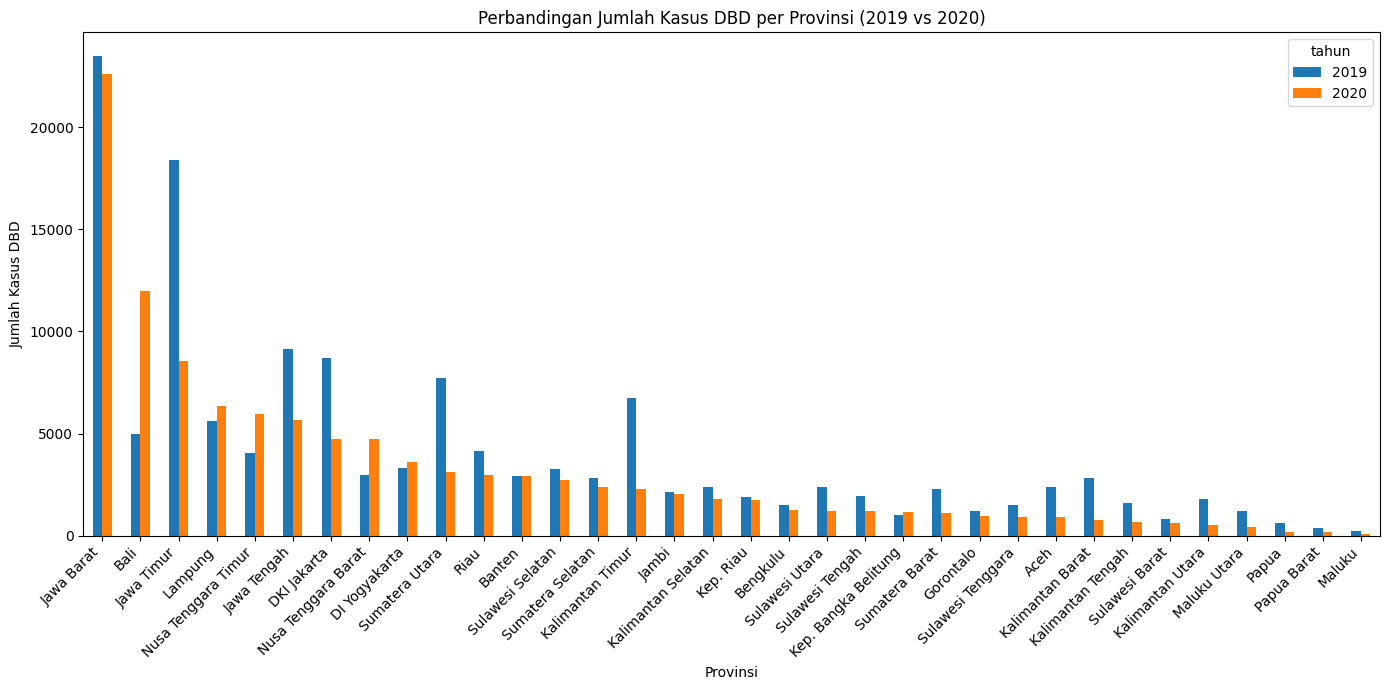

In [ ]:
import matplotlib.pyplot as plt

# Pivot tabel: Provinsi vs Tahun, dengan nilai jumlah kasus (JK)
df_prov_cases = df_gabungan.pivot_table(
    index='provinsi',
    columns='tahun',
    values='JK',
    aggfunc='sum'   # bisa sum karena tiap provinsi muncul 1x per tahun
)

# Pastikan kolom tersortir 2020 diurutkan
df_prov_cases = df_prov_cases.sort_values(by=2020, ascending=False)

# Plot
df_prov_cases.plot(kind='bar', figsize=(14, 7))
plt.title('Perbandingan Jumlah Kasus DBD per Provinsi (2019 vs 2020)')
plt.ylabel('Jumlah Kasus DBD')
plt.xlabel('Provinsi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("bar_chart.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Scatter Plot Suhu (Tavg) vs Incidence Rate DBD 2019 dan 2020

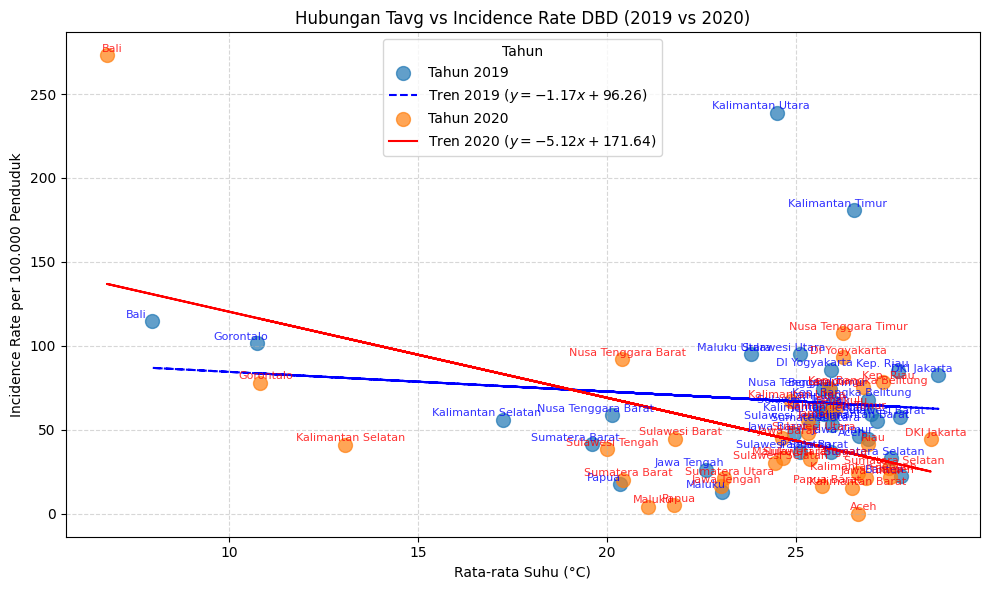

In [ ]:
plt.figure(figsize=(10, 6))

colors = {2019: 'blue', 2020: 'red'}
line_styles = {2019: '--', 2020: '-'}

# Loop untuk memplot data 2019 dan 2020 dengan warna berbeda
for year, group in df_gabungan.groupby('tahun'):
    plt.scatter(
        group['Tavg'],
        group['IR'],
        label=f'Tahun {year}',
        alpha=0.7,
        s=100
    )

    # Menambahkan label provinsi
    for i in range(len(group)):
        provinsi_name = group.iloc[i]['provinsi']

        # Offset posisi label
        x_offset = -0.015 * max(group['Tavg']) if year == 2019 else 0.005 * max(group['Tavg'])
        y_offset = 2

        plt.text(
            group.iloc[i]['Tavg'] + x_offset,
            group.iloc[i]['IR'] + y_offset,
            provinsi_name,
            fontsize=8,
            alpha=0.8,
            ha='center',
            color=colors[year]
        )

    # Garis Regresi
    X = group['Tavg']
    Y = group['IR']

    z = np.polyfit(X, Y, 1)
    p = np.poly1d(z)

    plt.plot(
        X,
        p(X),
        color=colors[year],
        linestyle=line_styles[year],
        label=f'Tren {year} ($y={z[0]:.2f}x+{z[1]:.2f}$)'
    )

plt.title('Hubungan Tavg vs Incidence Rate DBD (2019 vs 2020)')
plt.xlabel('Rata-rata Suhu (°C)')
plt.ylabel('Incidence Rate per 100.000 Penduduk')
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("scatter_tavg_IR.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Scatter Plot Curah Hujan (RR) vs Incidence Rate DBD 2019 dan 2020

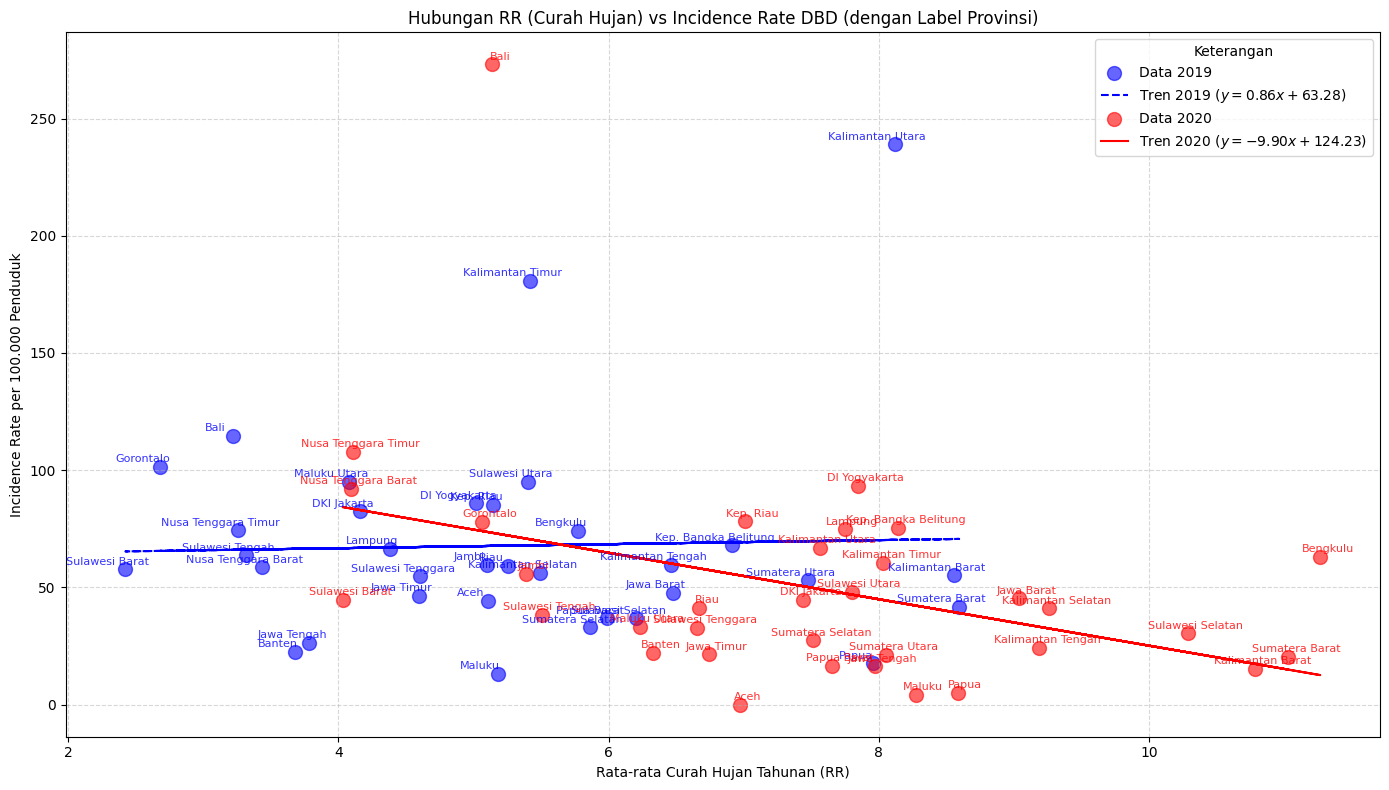

In [ ]:
plt.figure(figsize=(14, 8))  # Memperbesar ukuran untuk menghindari label bertumpuk

colors = {2019: 'blue', 2020: 'red'}
line_styles = {2019: '--', 2020: '-'}

# Loop per tahun
for year, group in df_gabungan.groupby('tahun'):

    # Scatter plot
    plt.scatter(
        group['RR'],
        group['IR'],
        label=f'Data {year}',
        alpha=0.6,
        s=100,
        color=colors[year]
    )

    # Tambahkan label provinsi
    for i in range(len(group)):
        provinsi_name = group.iloc[i]['provinsi']

        x_offset = -0.015 * max(group['RR']) if year == 2019 else 0.005 * max(group['RR'])
        y_offset = 2

        plt.text(
            group.iloc[i]['RR'] + x_offset,
            group.iloc[i]['IR'] + y_offset,
            provinsi_name,
            fontsize=8,
            alpha=0.8,
            ha='center',
            color=colors[year]
        )

    # Garis regresi
    X = group['RR']
    Y = group['IR']

    z = np.polyfit(X, Y, 1)  # slope & intercept
    p = np.poly1d(z)

    plt.plot(
        X,
        p(X),
        color=colors[year],
        linestyle=line_styles[year],
        label=f'Tren {year} ($y={z[0]:.2f}x+{z[1]:.2f}$)'
    )

plt.title('Hubungan RR (Curah Hujan) vs Incidence Rate DBD (dengan Label Provinsi)')
plt.xlabel('Rata-rata Curah Hujan Tahunan (RR)')
plt.ylabel('Incidence Rate per 100.000 Penduduk')
plt.legend(title='Keterangan')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("scatter_RR_IR.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Heatmap Matriks Korelasi Tahun 2019

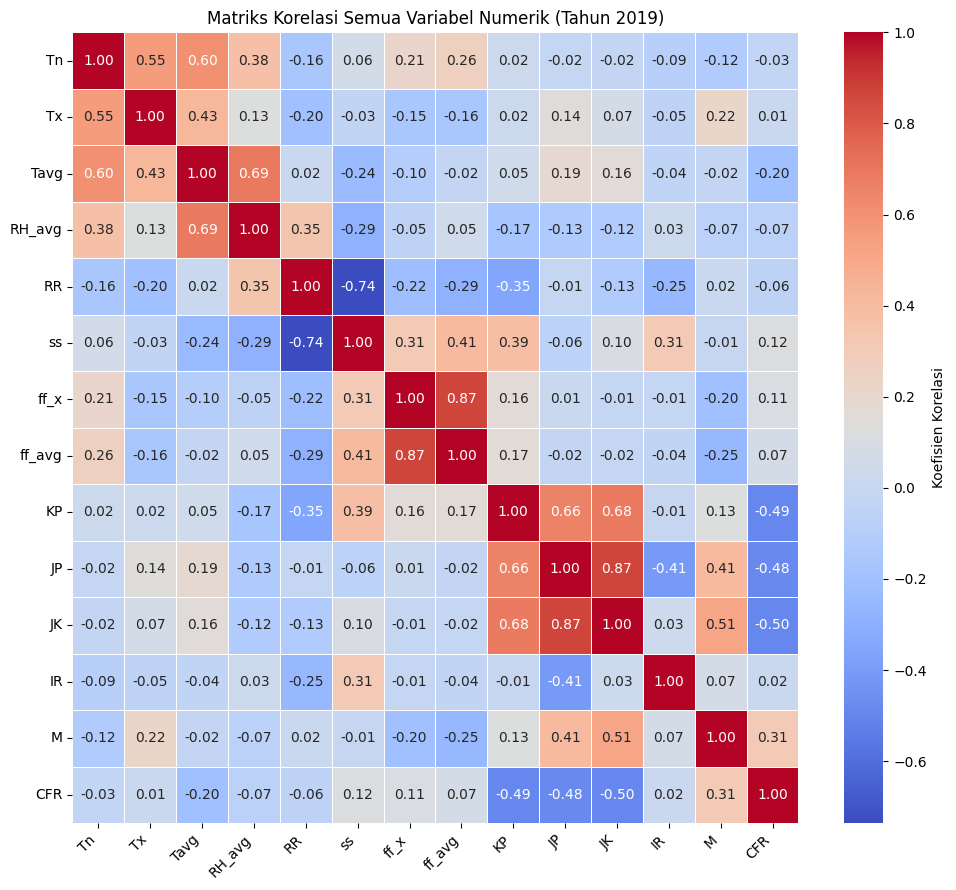

In [ ]:
# Filter hanya tahun 2019
df_2019 = df_gabungan[df_gabungan["tahun"] == 2019]

# Pilih semua kolom numerik saja
df_num_2019 = df_2019.select_dtypes(include=['int64', 'float64'])
df_num_2019 = df_num_2019.drop(columns=['tahun'], errors='ignore')

# Hitung Matriks Korelasi
df_corr_matrix = df_num_2019.corr(method="spearman")

# Plot Heatmap
plt.figure(figsize=(10, 9))
sns.heatmap(
    df_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Koefisien Korelasi'}
)

plt.title('Matriks Korelasi Semua Variabel Numerik (Tahun 2019)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("heatmap_2019.png", dpi=300, bbox_inches='tight')
plt.show()

## Heatmap Matriks Korelasi Tahun 2020

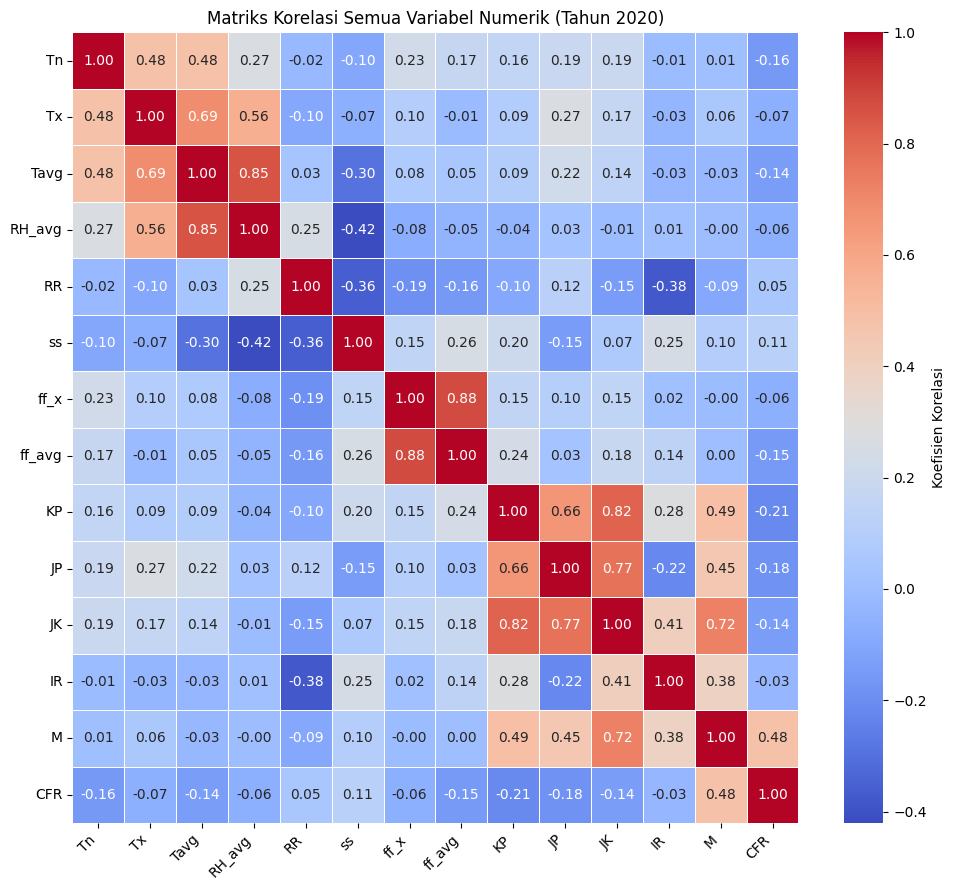

In [ ]:
# Filter hanya tahun 2020
df_2020 = df_gabungan[df_gabungan["tahun"] == 2020]

# Pilih semua kolom numerik saja
df_num_2020 = df_2020.select_dtypes(include=['int64', 'float64'])
df_num_2020 = df_num_2020.drop(columns=['tahun'], errors='ignore')

# Hitung Matriks Korelasi
df_corr_matrix = df_num_2020.corr(method="spearman")

# Plot Heatmap
plt.figure(figsize=(10, 9))
sns.heatmap(
    df_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Koefisien Korelasi'}
)

plt.title('Matriks Korelasi Semua Variabel Numerik (Tahun 2020)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("heatmap_2020.png", dpi=300, bbox_inches='tight')
plt.show()

## Scatter Plot (perbandingan) Kepadatan Penduduk vs Incidence Rate per 100.000 penduduk

> 2019

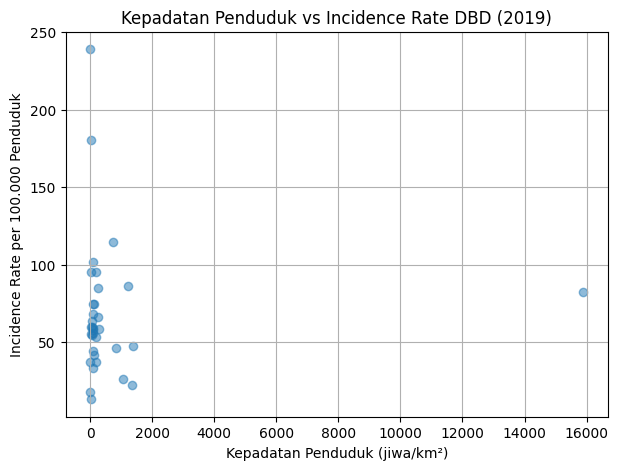

In [ ]:
# Filter tahun 2019
df_2019 = df_gabungan[df_gabungan["tahun"] == 2019]

plt.figure(figsize=(7,5))
plt.scatter(
    df_2019["KP"],     # Kepadatan Penduduk
    df_2019["IR"],     # Incidence Rate
    alpha=0.5
)
plt.title("Kepadatan Penduduk vs Incidence Rate DBD (2019)")
plt.xlabel("Kepadatan Penduduk (jiwa/km²)")
plt.ylabel("Incidence Rate per 100.000 Penduduk")
plt.grid()

plt.savefig("scatter_kepduk_IR_2019.png", dpi=300, bbox_inches='tight')
plt.show()

> 2020

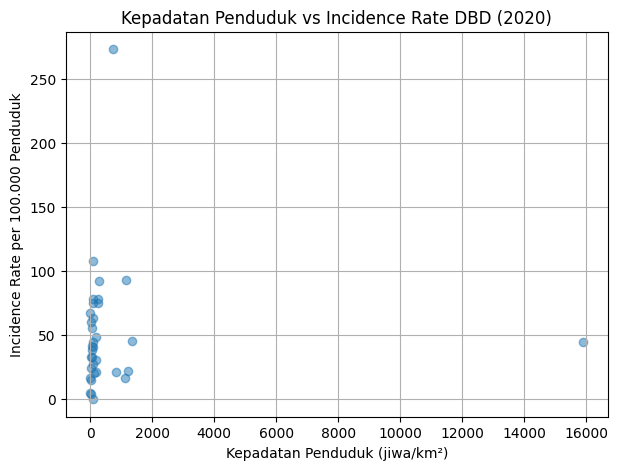

In [ ]:
# Filter tahun 2020
df_2020 = df_gabungan[df_gabungan["tahun"] == 2020]

plt.figure(figsize=(7,5))
plt.scatter(
    df_2020["KP"],     # Kepadatan Penduduk
    df_2020["IR"],     # Incidence Rate
    alpha=0.5
)
plt.title("Kepadatan Penduduk vs Incidence Rate DBD (2020)")
plt.xlabel("Kepadatan Penduduk (jiwa/km²)")
plt.ylabel("Incidence Rate per 100.000 Penduduk")
plt.grid()

plt.savefig("scatter_kepduk_IR_2020.png", dpi=300, bbox_inches='tight')
plt.show()

# **DATA PUBLISHING**

Github Project Akhir Data Wrangling - 2024C:

[9_Laili Nurrohmatul Fadhila Zulfa_Siti Fadilah Nurkhotimah_REVISI](https://github.com/SitiFadilahNurkhotimah/9_Laili-Nurrohmatul-Fadhila-Zulfa_Siti-Fadilah-Nurkhotimah_2024C_Projek_Akhir_Data_Wrangling_REVISI)